# Numerisches Praktikum - Florian Grifone

The goal of this experiment is to study the interpolation of the $\mathcal{C}^{\infty}$ function $$f_{s, \epsilon}(x_1,x_2) = \frac{1}{(x_1^2 + x_2^2 + \epsilon)^s}$$ on the two dimensional unit triangle
$$T = \{(x_1,x_2)\in [0,1]^2 \text{, s.t. } x_1 + x_2 \leq 1\} $$ 

From the theory of Numerical Analysis in one dimension we know that for a function $f\in\mathcal{C}^{k+1}$ we :
$$ ||(f - I_k(f))||_{\infty} \leq \frac{||f^{(k+1)}||_{\infty}}{(k+1)!}||\omega_{\theta}|| $$

#### Packages:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from copy import deepcopy 
from scipy.special import roots_legendre, roots_jacobi
from scipy.special import eval_jacobi as jacobi
from scipy.special import eval_legendre as legendre
import numpy.polynomial as poly
from tqdm import tqdm


### Implementation of functions

Firstly we implement a function that computes us the set of equidistant nodal points on $T$, and also returns the indices of the nodal points:

In [5]:
def equid(k):
    
    "define x and y axis nodal points"
    x = np.linspace(0,k,k+1)
    y = np.linspace(0,k,k+1)
    
    "prepare nodal point matrix with integer values"
    theta_int = np.zeros((2,int((k+1)*(k+2)/2)))
    index = 0
    
    "create nodal points s.t. sum of vector components less than k"
    for x_l in x:
        for y_j in y:
            if x_l + y_j <= k:
                theta_int[:,index] = [x_l, y_j]
                index = index + 1
                
    theta = deepcopy(theta_int)
    i_set = np.arange(int((k+1)*(k+2)/2))
    "divide each component by k to have coordinates in unit triangle"
    for i in i_set:
        theta[0,int(i)] = theta[0,int(i)]/k
    for i in i_set:
        theta[1,int(i)] = theta[1,int(i)]/k
        
    'theta = np.transpose(theta)'
    'theta_int = np.transpose(theta_int)'
    return [theta, theta_int]

Now we define the function we want to interpolate:

In [6]:
def f(x, epsilon, s):
    
    "define interpolated function with changeable parameter epsilon and s"
    f = 1/((x[0]**2 + x[1]**2 + epsilon)**s)
    return f

Aswell as we define two test polynomials and check if our polynomial interpolations fit polynomials perfectly:

In [7]:
def p(x, m):
    
    p_value = 0
    
    if m < 4:
        print('too low degree')
        
    else:
        p_value = 2*(x[0]**m) - 3*(x[1]**m) + 2*(x[0]**4)*(x[1]**3) - x[0] + 2*(x[1]**2)
    
    return p_value

In [8]:
def q(x, m):
    
    q_value = 3*x[0] - 2*x[1]
    
    return q_value

Next we define the Lagrange basis functions on $T$, computed after the reference ___ :

In [9]:
def Lagrange_function(i,j,k,x,y):
    if i+j > k:
        print('Error in choice of index')
    
    else:
        index_1 = np.array(range(0,i,1))
        index_2 = np.array(range(0,j,1))
        index_3 = np.array(range(0,k-i-j,1))
        product_1 = 1
        product_2 = 1
        product_3 = 1
        for l in index_1:
            product_1 = product_1*(x-l/k)
        for n in index_2:
            product_2 = product_2*(y-n/k)
        for m in index_3:
            product_3 = product_3*(1-x-y - m/k)
        L_ijk_xy = product_1*product_2*product_3
        return L_ijk_xy

The next function just normalizes all the Lagrange basis functions:

In [10]:
def Lagrange_function_norm(i,j,k,x,y):
    norm = Lagrange_function(i, j, k, i/k, j/k)
    L_ijk_xy_norm = Lagrange_function(i,j,k,x,y)/norm
    return  L_ijk_xy_norm

The last step is to Lagrange interpolate the function $f$ at the equidistant nodal points:

In [11]:
def Lagrange_interpol(x,y,k,epsilon,s):
    L_f = 0
    theta_int = np.transpose(equid(k)[1])
    "theta = np.transpose(equid(k)[0])"
    summands = np.zeros((int((k+1)*(k+2)/2),1))
    sum_index = 0
    for ij in theta_int:
        summands[sum_index] = f(ij/k,epsilon,s)*Lagrange_function_norm(int(ij[0]),int(ij[1]),k,x,y)
        sum_index = sum_index + 1
    L_f = np.sum(summands)
    return L_f

Now we define the functions for our optimized polynomial interpolation. For this we take symmetrised Gauss Lobatto Nodes, which are the roots of $L^2([a,b], \mathbb{R})$ orthogonal polynomials, called Lobatto polynomials. Recall that polynomials on $[a,b]$ are a subspace of $L^2([a,b], \mathbb{R})$ and two functions $f, g \in L^2([a,b], \mathbb{R})$ are said to be orthogonal if and only if:
$$ \langle f, g \rangle_{L^2([a,b])} = \int_{[a,b]}f(x)g(x) \ dx = 0 $$

A Lobatto polynomial is $\frac{d}{dx}P^{(0,0)}_n(x) = \frac{n+1}{2}P^{(0+1,0+1)}_{n-1}(x)$ where $P^{(\alpha,\beta)}_n$ is the $n$-th Jacobi polynomial. The Jacobi polynomials verify the equation:
$$\forall n, m: \ \int_{[-1, 1]} (1+x)^{\alpha}(1+x)^{\beta}P^{(\alpha,\beta)}_n(x) P^{(\alpha,\beta)}_m(x) dx = 0 $$

In [12]:
def gauss_lobatto_nodes(m):
    #Lebatto polyonomial = derivative of Jacobi polynomial with alpha = beta = 0 = (n-1)P^{a}
    
    lobatto_roots = np.sort(roots_jacobi(m-1, 1,1, mu = False)[0])
    v = [(1/2)*(1+t_i) for t_i in lobatto_roots]
    v = np.append(v, 1)
    v = np.insert(v, 0, 0)

    gl_grid = np.zeros((int((1/2)*(m+1)*(m+2)),2))
    index = 0
    for i in range(0, m + 1, 1):
        for j in range(0, m + 1 - i, 1):
            #print((i,j))
            ksi_i = (1/3)*(1 + 2*v[j] - v[i] - v[m - i - j])
            eta_j = (1/3)*(1 + 2*v[i] - v[j] - v[m - i - j])
            gl_grid[index] = [ksi_i, eta_j]
            index = index + 1
    
    return gl_grid
    

The reason we are using this set of nodes, is that since the error is expected to be higher at the edges and even more so at the vertices of the triangle, we want to have nodal points that are more densely distributed at these locations. Below is a visualization of the set of symmetrized Gauss Lobatto nodes.

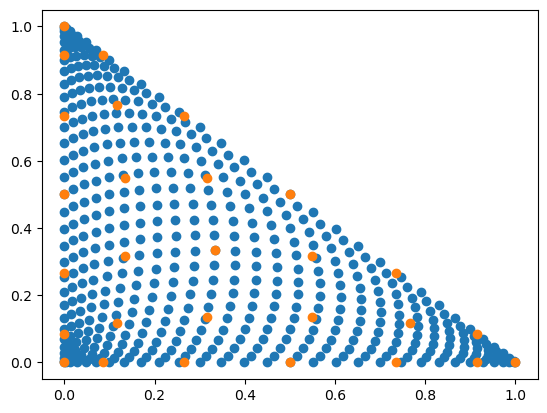

In [13]:
m = 6

nodes = gauss_lobatto_nodes(m)
test_set_sample = gauss_lobatto_nodes(5*m)
plt.scatter(np.transpose(test_set_sample)[0], np.transpose(test_set_sample)[1])
plt.scatter(np.transpose(nodes)[0], np.transpose(nodes)[1])

plt.show()

In [11]:
def powers_x(m):
    p_x =[]
    for ind in range(0, m+1, 1):

        for k in range (0, ind+1, 1):
            p_x.append(ind-k)
    return p_x

In [12]:
def powers_y(m):
    p_y = []
    for ind in range(0, m+1, 1):

        for k in range (0, ind+1, 1):
            p_y.append(k)
    return p_y

In [13]:
def van_der_monde_matrix(m, nodes):
    
    N = int((m+1)*(m+2)/2)
    V = np.zeros((N, N))
    p_x = powers_x(m)
    p_y = powers_y(m)
    
    for k in range(0, N, 1):
        V[k] = [(nodes[k][0]**p_x[i])*(nodes[k][1]**p_y[i]) for i in range(0, N, 1)]
    
    return V

In [14]:
def proriol(k, l, ksi, eta):
    #print(eta)
    if np.shape(eta) == ():
        if eta != 1:
            ksi_p = (2*ksi)/(1-eta) - 1
        else:
            ksi_p = 0
        eta_p = 2*eta - 1
    else:
        ksi_p = np.zeros(len(ksi))
        eta_p = np.zeros(len(eta))
        for i in range(0,len(eta)):
            if eta[i] != 1:
                ksi_p[i] = (2*ksi[i])/(1-eta[i]) - 1
            else:
                ksi_p[i] = 0
            eta_p[i] = 2*eta[i] - 1
    
    proriol = legendre(k, ksi_p)*((1-eta)**k)*jacobi(l, 2*k+1, 0, eta_p)
    return proriol

In [15]:
def pro_vdr_row(ksi, eta, m):
    
    k = powers_x(m)
    l = powers_y(m)
    proriols = [proriol(k[i], l[i], ksi, eta) for i in range(0,len(k))]
    
    return proriols

In [16]:
def pro_vdr_row_old(ksi, eta, m):
    print(len(eta))
    if eta != 1:
        ksi_p = (2*ksi)/(1-eta) - 1
    else:
        ksi_p = 0
    eta_p = 2*eta - 1
    
    k = powers_x(m)
    l = powers_y(m)
    proriols = [legendre(k[i], ksi_p)*((1-eta)**k[i])*jacobi(l[i], 2*k[i]+1, 0, eta_p) for i in range(0,len(k))]
    
    return proriols

In [17]:
def pro_vdr_matrix(m, nodes):

    N = int((m+1)*(m+2)/2)
    V = np.zeros((N,N))
    
    for i in range(0, N):
        V[i] = pro_vdr_row(nodes[i][0], nodes[i][1], m)

    return V
    

In [18]:
def pro_vdr_coeff(m, nodes):
    V = pro_vdr_matrix(m, nodes)
    [Q, R] = np.linalg.qr(V)
    N = int((m+1)*(m+2)/2)
    basis = np.eye(N)
    B = np.zeros((N,N))
    
    for i in range(0,N,1):
        B[:][i] = np.linalg.solve(R, np.matmul(np.transpose(Q), np.transpose(basis[i])))

    return B

In [19]:
def pro_psi_i(x, m, i, nodes):
    N = int((m+1)*(m+2)/2)
    B = pro_vdr_coeff(m, nodes)
    k = powers_x(m)
    l = powers_y(m)
    chi = pro_vdr_row(x[0], x[1], m)
    #print(np.shape(chi))
    b_i = np.transpose(B[i])
    #print(np.shape(b_i))
    psi_i = np.matmul(np.transpose(chi), b_i)

    return psi_i

In [20]:
def pro_interpol(x, m, nodes, epsilon, s):
    N = int((m+1)*(m+2)/2)
    f_values = np.asarray(f(np.transpose(nodes), epsilon, s))
    psi_values = np.transpose(np.asarray([pro_psi_i(x, m, i, nodes) for i in range(0, N)]))
    #print(np.shape(f_values), np.shape(psi_values))
    psi = np.matmul(psi_values, f_values)
    #print(np.shape(psi))
    return psi

In [21]:
def pro_interpol_indep(x, m, nodes, values):
    N = int((m+1)*(m+2)/2)
    psi_values = np.transpose(np.asarray([pro_psi_i(x, m, i, nodes) for i in range(0, N)]))
    #print(np.shape(values), np.shape(psi_values))
    psi = np.matmul(psi_values, np.transpose(values))
    return psi

In [24]:
# test if interpolation perfectly interpolates polynomial
m = 7

nodals = gauss_lobatto_nodes(m)
eval_points = gauss_lobatto_nodes(5*m)
values = p(np.transpose(nodals), m)
psi_values = pro_interpol_indep(np.transpose(eval_points), m , nodals, values)
print(np.shape(psi_values))
p_values = p(np.transpose(eval_points), m)
print(np.shape(p_values))

print(np.max(abs(p_values - psi_values)))


(666,)
(666,)
1.6653345369377348e-15


### Experiments

Firstly we will verify for fixed regularization and singularity parameters $\epsilon$ and $s$ wether the maximal error of the Lagrange interpolation decreases for increasing polynomial degree:

100%|██████████████████████████████████████████████████████████████████████████████████| 29/29 [24:41<00:00, 51.09s/it]

[2.06896552e-01 6.49886649e-16 7.76078231e-16 1.49453099e-15
 2.21689901e-15 2.37262989e-15 4.62518013e-15 2.83954982e-15
 7.99173637e-15 1.95321124e-14 2.53047198e-14 9.63405973e-14
 7.76696533e-14 3.21850792e-13 1.97806577e-13 9.63707047e-14
 4.80264399e-13 3.58668405e-12 4.48880935e-12 1.75378055e-11
 1.55192933e-11 6.24591136e-11 3.06999448e-11 2.21229933e-10
 5.78563251e-10 1.05614175e-09 1.16790255e-09 4.44177215e-09
 2.33549676e-09]


Text(0, 0.5, 'MaxNorm - error')

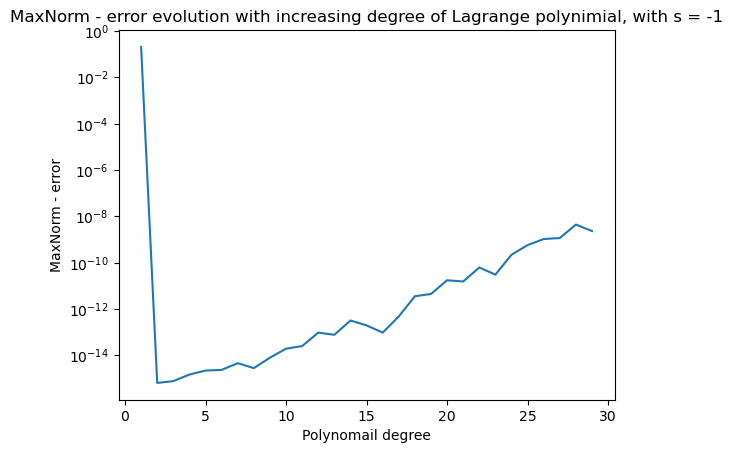

In [35]:
poly_deg_k_minus = np.array(range(1,30,1)) #Choice of polynomial degree
epsilon_k_minus = 2 #Choice of regularization parameter
s_k_minus = -1 #Choice of singularity parameter

err_k_minus = []
for k in tqdm(poly_deg_k_minus):
    test_set_k_minus = equid(5*k)[0] #test values for the interpolation
    f_values_k_minus = f(test_set_k_minus,epsilon_k_minus,s_k_minus)
    L_f_values_k_minus = np.asarray([Lagrange_interpol(x[0],x[1],k,epsilon_k_minus,s_k_minus) for x in np.transpose(test_set_k_minus)])
    err_k_minus = np.append(err_k_minus, np.max(abs((f_values_k_minus - L_f_values_k_minus)/f_values_k_minus)))
    #print(err)

print(err_k_minus)
error_plot_k_minus = plt.semilogy(poly_deg_k_minus,err_k_minus)
plt.title('MaxNorm - error evolution with increasing degree of Lagrange polynimial, with s = -1')
plt.xlabel('Polynomial degree')
plt.ylabel('MaxNorm - error')

In [22]:
poly_deg_k_0 = np.array(range(2,34,1)) #Choice of polynomial degree
epsilon_k_0 = 0.01 #Choice of regularization parameter
s_k_0 = -1/3 #Choice of singularity parameter

err_k = []
for k in tqdm(poly_deg_k_0):
    test_set_k_0 = equid(5*k)[0] #test values for the interpolation
    f_values_k_0 = f(test_set_k_0,epsilon_k_0,s_k_0)
    L_f_values_k_0 = np.asarray([Lagrange_interpol(x[0],x[1],k,epsilon_k_0,s_k_0) for x in np.transpose(test_set_k_0)])
    err_k = np.append(err_k, np.max(abs((f_values_k_0 - L_f_values_k_0)/f_values_k_0)))
    #print(err)

print(err_k_0)
error_plot_k_0 = plt.semilogy(poly_deg_k_0,err_k_0)
plt.title('MaxNorm - error evolution with increasing degree of Lagrange polynimial, with s = -1/3, epsilon = 0.01')
plt.xlabel('Polynomail degree')
plt.ylabel('MaxNorm - error')

100%|██████████████████████████████████████████████████████████████████████████████████| 32/32 [40:19<00:00, 75.60s/it]


NameError: name 'err_k_0' is not defined

Text(0, 0.5, 'MaxNorm - error')

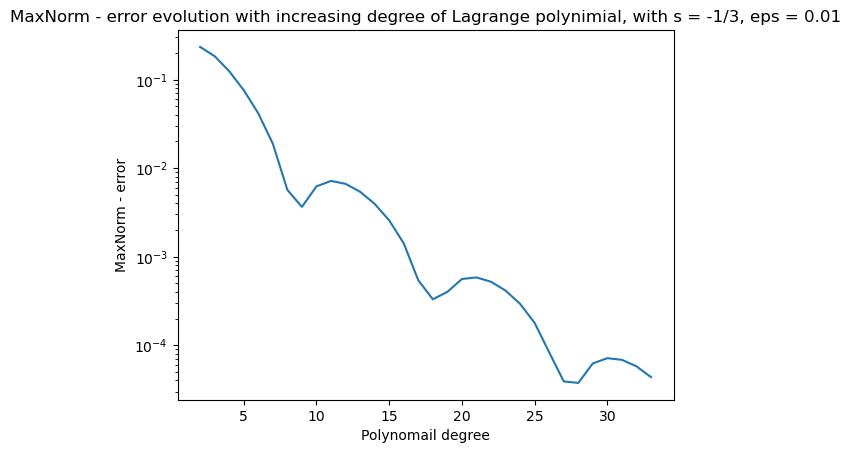

In [23]:
error_plot_k_0 = plt.semilogy(poly_deg_k_0,err_k)
plt.title('MaxNorm - error evolution with increasing degree of Lagrange polynimial, with s = -1/3, eps = 0.01')
plt.xlabel('Polynomail degree')
plt.ylabel('MaxNorm - error')

-0.27692945997292306


Text(0, 0.5, 'MaxNorm - error')

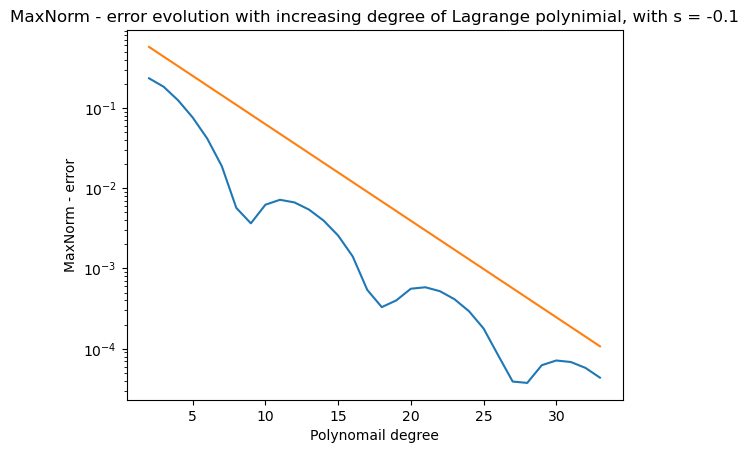

In [30]:
alpha_e001_s1_3 = np.mean(np.log(err_k[1:]/err_k[0:-1]))
print(alpha_e001_s1_3)
line_fit_e001_s1_3 = np.exp(alpha_e001_s1_3*poly_deg_k_0)

error_plot_k_0 = plt.semilogy(poly_deg_k_0,err_k)
plt.semilogy(poly_deg_k_0,line_fit_e001_s1_3)

plt.title('MaxNorm - error evolution with increasing degree of Lagrange polynimial, with s = -0.1')
plt.xlabel('Polynomail degree')
plt.ylabel('MaxNorm - error')

100%|██████████████████████████████████████████████████████████████████████████████████| 29/29 [25:49<00:00, 53.43s/it]

[14.01980198  6.89108911  3.61731195  1.84250553  0.81010295  0.48907962
  0.33372851  0.47938919  0.55195989  0.53697471  0.46557416  0.36501563
  0.25623123  0.1869429   0.17123277  0.15261224  0.13341467  0.11475216
  0.09812223  0.08373912  0.07206173  0.0626026   0.05524584  0.04930165
  0.04455244  0.04044609  0.03689157  0.03356459  0.03051448]


Text(0, 0.5, 'MaxNorm - error')

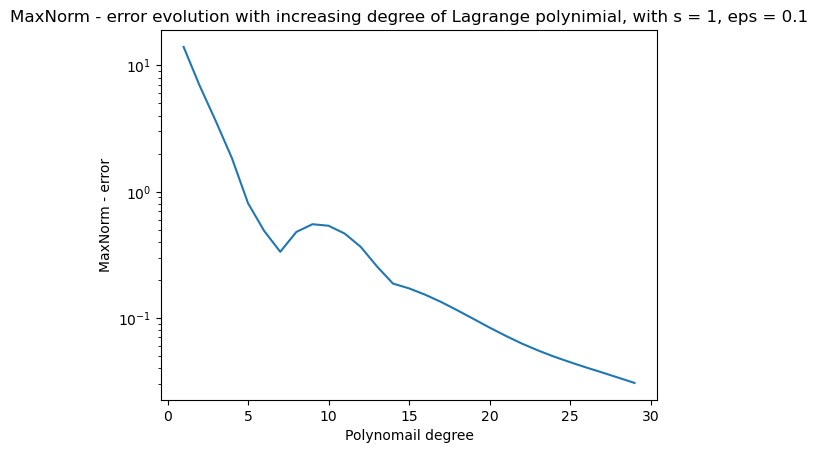

In [52]:
poly_deg_k_1 = np.array(range(1,30,1)) #Choice of polynomial degree
epsilon_k_1 = 0.01 #Choice of regularization parameter
s_k_1 = 1 #Choice of singularity parameter

err_k_1 = []
for k in tqdm(poly_deg_k_1):
    test_set_k_1 = equid(5*k)[0] #test values for the interpolation
    f_values_k_1 = f(test_set_k_1,epsilon_k_1,s_k_1)
    L_f_values_k_1 = np.asarray([Lagrange_interpol(x[0],x[1],k,epsilon_k_1,s_k_1) for x in np.transpose(test_set_k_1)])
    err_k_1 = np.append(err_k_1, np.max(abs((f_values_k_1 - L_f_values_k_1)/f_values_k_1)))
    #print(err)

print(err_k_1)
error_plot_k_1 = plt.semilogy(poly_deg_k_1,err_k_1)
plt.title('MaxNorm - error evolution with increasing degree of Lagrange polynimial, with s = 1, eps = 0.1')
plt.xlabel('Polynomail degree')
plt.ylabel('MaxNorm - error')

-0.21892944950044976


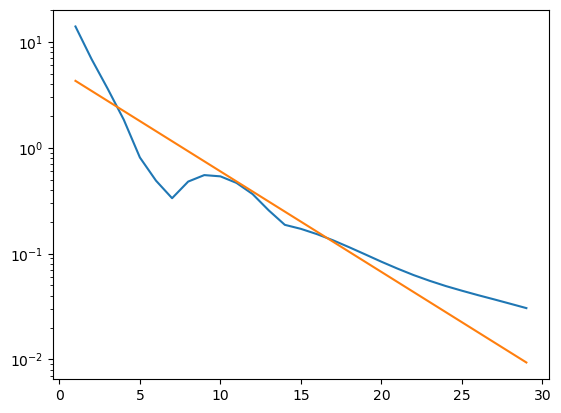

In [55]:
log_C_e01_s1 = np.mean((np.log(err_k_1[0:-1]*poly_deg_k_1[1:] - np.log(err_k_2[1:])*poly_deg_k_1[0:-1]))/(poly_deg_k_1[1:] - poly_deg_k_2[0:-1]))
alpha_e01_s1 = np.mean(np.log(err_k_1[1:]/err_k_1[0:-1]))
print(alpha_e01_s1)

line_fit_e01_s1 = log_C_e01_s1*(np.exp(alpha_e01_s1*poly_deg_k_2))

plt.semilogy(poly_deg_k_1,err_k_1)
plt.semilogy(poly_deg_k_1,line_fit_e01_s1)
plt.show()


100%|███████████████████████████████████████████████████████████████████████████████| 29/29 [1:23:11<00:00, 172.11s/it]

[1.60000000e-01 2.10133333e-02 6.43091787e-03 7.76778074e-04
 4.17809467e-04 4.39507302e-05 3.15396533e-05 3.69721688e-06
 2.56461344e-06 3.25290536e-07 2.26088932e-07 2.93329985e-08
 2.04616773e-08 2.69127534e-09 1.88280211e-09 2.50214546e-10
 1.75418980e-10 1.95289285e-11 1.91703480e-11 2.17031699e-11
 2.16059400e-11 8.85220963e-11 4.76482625e-11 3.08869327e-10
 4.52624150e-10 1.56710738e-09 1.02351520e-09 4.69767557e-09
 2.44655501e-09]


Text(0, 0.5, 'MaxNorm - error')

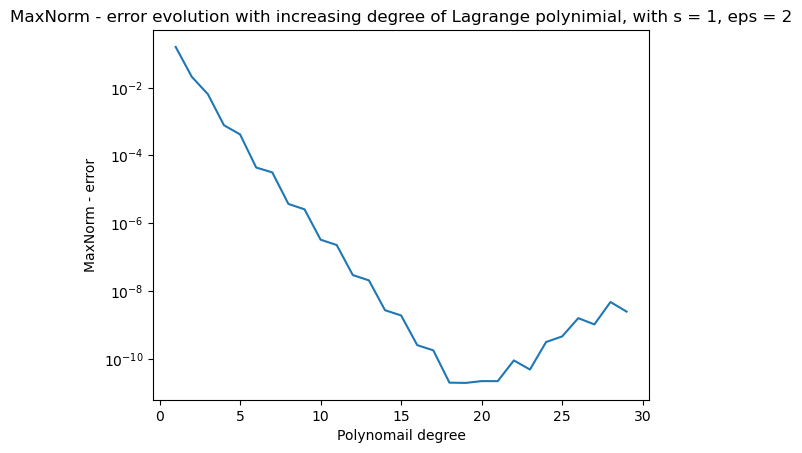

In [28]:
poly_deg_k_2 = np.array(range(1,30,1)) #Choice of polynomial degree
epsilon_k_2 = 2 #Choice of regularization parameter
s_k_2 = 1 #Choice of singularity parameter

err_k_2 = []
for k in tqdm(poly_deg_k_2):
    test_set_k_2 = equid(5*k)[0] #test values for the interpolation
    f_values_k_2 = f(test_set_k_2,epsilon_k_2,s_k_2)
    L_f_values_k_2 = np.asarray([Lagrange_interpol(x[0],x[1],k,epsilon_k_2,s_k_2) for x in np.transpose(test_set_k_2)])
    err_k_2 = np.append(err_k_2, np.max(abs((f_values_k_2 - L_f_values_k_2)/f_values_k_2)))
    #print(err)

print(err_k_2)
error_plot_k_2 = plt.semilogy(poly_deg_k_2,err_k_2)
plt.title('MaxNorm - error evolution with increasing degree of Lagrange polynimial, with s = 1, eps = 2')
plt.xlabel('Polynomail degree')
plt.ylabel('MaxNorm - error')

In [83]:
#fit line on error curve for f with eps = 2 and s = 1

rho_e2_s1 = np.mean(np.exp((np.log(err_k_2[1:]) - np.log(err_k_2[0:-1]))/(poly_deg_k_2[1:] - poly_deg_k_2[0:-1])))
log_C_e2_s1 = np.mean((np.log(err_k_2[0:-1])*poly_deg_k_2[1:] - np.log(err_k_2[1:])*poly_deg_k_2[0:-1])/(poly_deg_k_2[1:] - poly_deg_k_2[0:-1]))
alpha_e2_s1 = np.mean(np.log(err_k_2[1:]/err_k_2[0:-1]))
print(alpha_e2_s1)
print(rho_e2_s1)
print(log_C_e2_s1)
#print(np.log(err_k_2[0:-1]))
#print(err_k_2[0:-1])

-0.6427144090916567
1.109772687791887
-13.748208360121378


[5.25863077e-01 2.76531976e-01 1.45417956e-01 7.64699339e-02
 4.02127148e-02 2.11463819e-02 1.11201015e-02 5.84765079e-03
 3.07506364e-03 1.61706243e-03 8.50353426e-04 4.47169469e-04
 2.35149913e-04 1.23656657e-04 6.50264702e-05 3.41950198e-05
 1.79818983e-05 9.45601639e-06 4.97256988e-06 2.61489090e-06
 1.37507458e-06 7.23100949e-07 3.80252090e-07 1.99960534e-07
 1.05151862e-07 5.52954817e-08 2.90778522e-08 1.52909688e-08
 8.04095593e-09]


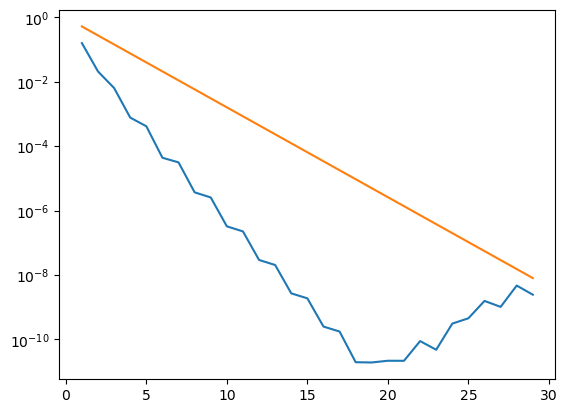

In [85]:
line_fit_e2_s1 = np.exp(alpha_e2_s1*poly_deg_k_2)
print(line_fit_e2_s1)
plt.semilogy(poly_deg_k_2,err_k_2)
plt.semilogy(poly_deg_k_2,line_fit_e2_s1)
plt.show()

-1.2894538979157426


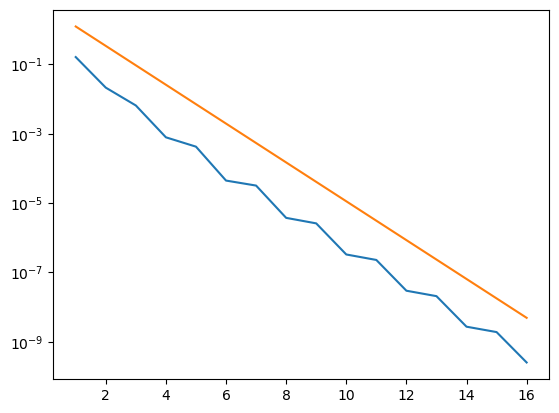

In [54]:
rho_e2_s1_cut = np.mean(np.exp((np.log(err_k_2[1:17]) - np.log(err_k_2[0:16]))/(poly_deg_k_2[1:17] - poly_deg_k_2[0:16])))
log_C_e2_s1_cut = np.mean((np.log(err_k_2[0:16]*poly_deg_k_2[1:17] - np.log(err_k_2[1:17])*poly_deg_k_2[0:16]))/(poly_deg_k_2[1:17] - poly_deg_k_2[0:16]))
alpha_e2_s1_cut = np.mean(np.log(err_k_2[1:17]/err_k_2[0:16]))
print(alpha_e2_s1_cut)

line_fit_e2_s1_cut = log_C_e2_s1_cut*(np.exp(alpha_e2_s1_cut*poly_deg_k_2[0:16]))
plt.semilogy(poly_deg_k_2[0:16], err_k_2[0:16])
plt.semilogy(poly_deg_k_2[0:16], line_fit_e2_s1_cut)


17 percent with 0.01 epsilon
251 percent with 0.001 epsilon

Next we look at how the interpolation performs if we vary the regularization parameter; the smaller it is the larger 
the value of $f$ at the origin. In general we expect the interpolation to perform worse as $\epsilon \rightarrow 0$,
because $f$ then leaves the space of continuous functions, while the interpolation is a polynomial and thus can't capture singularities well. We will still increase the degree of polynomials to keep things fair.

100%|██████████████████████████████████████████████████████████████████████████████████| 11/11 [01:02<00:00,  5.73s/it]


Text(0, 0.5, 'MaxNorm - error')

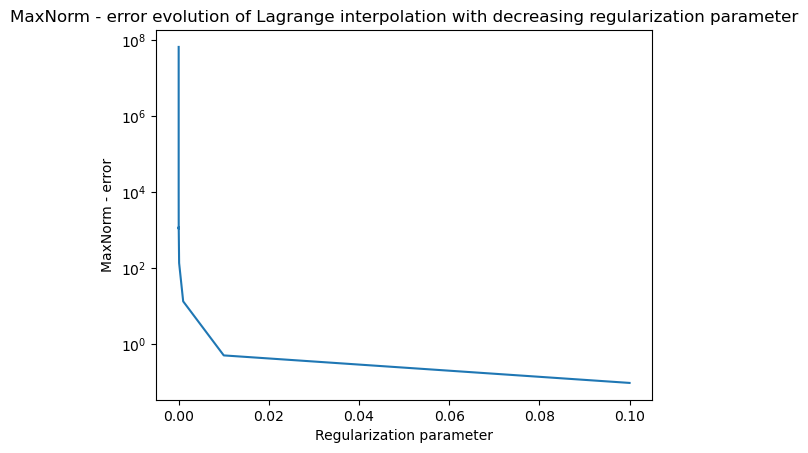

In [67]:
epsilon_vector = [0.1, 0.01, 0.001, 0.0001, 0.00001, 0.00001, 0.000001, 0.0000001, 0.00000001, 0.000000001, 0.0000000001]
poly_deg_eps = np.array(range(5,16,1))
s_eps = 1

eps_index = 0
err_eps = []

for k in tqdm(poly_deg_eps):
    loop_eps = epsilon_vector[eps_index]
    test_set_eps = equid(5*k)[0] #test values for the interpolation
    f_values_eps = f(test_set_eps,loop_eps,s_eps)
    L_f_values_eps = np.asarray([Lagrange_interpol(x[0],x[1],k,loop_eps,s_eps) for x in np.transpose(test_set_eps)])
    err_eps = np.append(err_eps, np.max(abs((f_values_eps - L_f_values_eps)/f_values_eps)))
    eps_index = eps_index + 1


error_plot = plt.semilogy(epsilon_vector,err_eps)
plt.title('MaxNorm - error evolution of Lagrange interpolation with decreasing regularization parameter')
plt.xlabel('Regularization parameter')
plt.ylabel('MaxNorm - error')

Text(0, 0.5, 'MaxNorm - error')

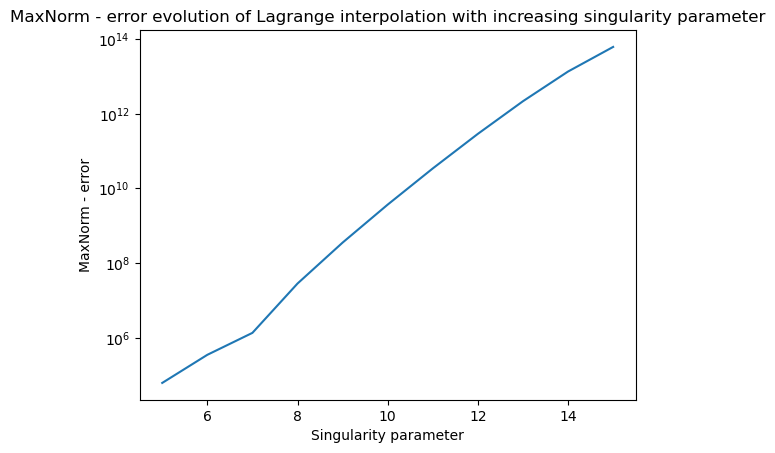

In [13]:
s_vector = np.array(range(5,16,1))
poly_deg_eps = np.array(range(1,12,1))
epsilon_s = 0.1

s_index = 0
err_s = []

for k in poly_deg_eps:
    loop_s = s_vector[s_index]
    test_set_s = equid(5*k)[0] #test values for the interpolation
    f_values_s = f(test_set_s,epsilon_s,loop_s)
    L_f_values_s = np.asarray([Lagrange_interpol(x[0],x[1],k,epsilon_s,loop_s) for x in np.transpose(test_set_s)])
    err_s = np.append(err_s, np.max(abs((f_values_s - L_f_values_s)/f_falues_s)))
    s_index = s_index + 1


error_plot = plt.semilogy(s_vector,err_s)
plt.title('MaxNorm - error evolution of Lagrange interpolation with increasing singularity parameter')
plt.xlabel('Singularity parameter')
plt.ylabel('MaxNorm - error')

In [26]:
deg_vector_pro_e2_s1 = np.array(range(2, 45))
eps_2_p = 2
s_e2_p = 1
err_e2_s1_p = []

for m in tqdm(deg_vector_pro_e2_s1):
    nodals_e2_s1_p = gauss_lobatto_nodes(m)
    test_e2_s1_p = gauss_lobatto_nodes(5*m)
    f_values_pro_e2_s1 = f(np.transpose(test_e2_s1_p), eps_2_p, s_e2_p)
    Psi_f_values_e2_s1_p = np.asarray(pro_interpol(np.transpose(test_e2_s1_p), m, nodals_e2_s1_p, eps_2_p, s_e2_p))
    err_e2_s1_p.append(np.max(abs((f_values_pro_e2_s1 - Psi_f_values_e2_s1_p)/f_values_pro_e2_s1)))


error_plot = plt.semilogy(deg_vector_pro_e2_s1, err_e2_s1_p)
plt.title('MaxNorm - error evolution of Proriol polyn. interpol. with symm. Gauss-Lobatto nodes eps = 2, s=1')
plt.xlabel('Polynomial degree')
plt.ylabel('MaxNorm - error')

 77%|█████████████████████████████████████████████████████████▌                 | 33/43 [12:41:50<3:50:51, 1385.17s/it]


KeyboardInterrupt: 

Text(0, 0.5, 'maximal relative error')

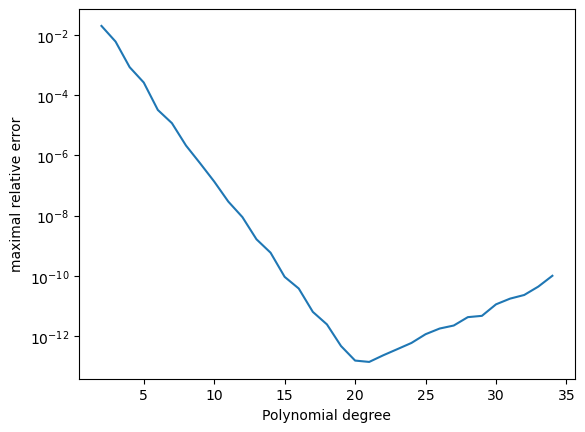

In [33]:
plt.semilogy(deg_vector_pro_e2_s1[0:33], err_e2_s1_p)
plt.xlabel('Polynomial degree')
plt.ylabel('maximal relative error')

-0.5966374520785207


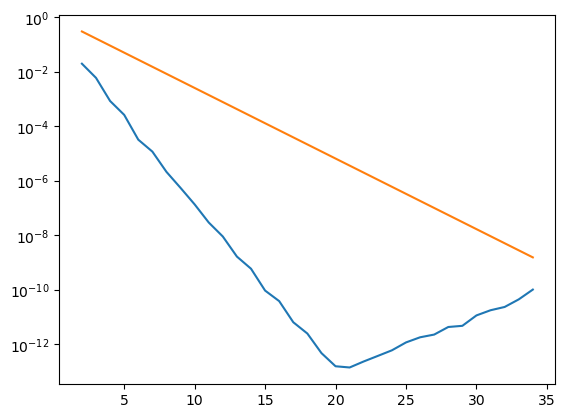

In [28]:
alpha_e2_s1_p = np.mean(np.log(np.array(err_e2_s1_p[1:])/np.array(err_e2_s1_p[0:-1])))
print(alpha_e2_s1_p)

line_fit_p_e2_s1 = np.exp(alpha_e2_s1_p*deg_vector_pro_e2_s1[0:33])

plt.semilogy(deg_vector_pro_e2_s1[0:33], err_e2_s1_p)
plt.semilogy(deg_vector_pro_e2_s1[0:33], line_fit_p_e2_s1)
plt.show()

-1.351326730541018


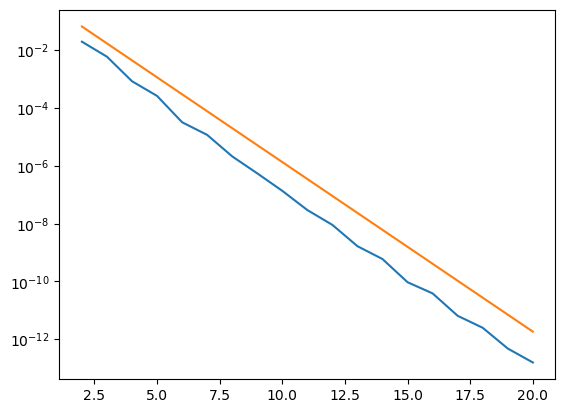

In [30]:
alpha_e2_s1_p = np.mean(np.log(np.array(err_e2_s1_p[1:20])/np.array(err_e2_s1_p[0:19])))
print(alpha_e2_s1_p)

line_fit_p_e2_s1 = np.exp(alpha_e2_s1_p*deg_vector_pro_e2_s1[0:19])

plt.semilogy(deg_vector_pro_e2_s1[0:19], err_e2_s1_p[0:19])
plt.semilogy(deg_vector_pro_e2_s1[0:19], line_fit_p_e2_s1)
plt.show()

100%|█████████████████████████████████████████████████████████████████████████████| 33/33 [11:03:52<00:00, 1207.04s/it]


Text(0, 0.5, 'MaxNorm - error')

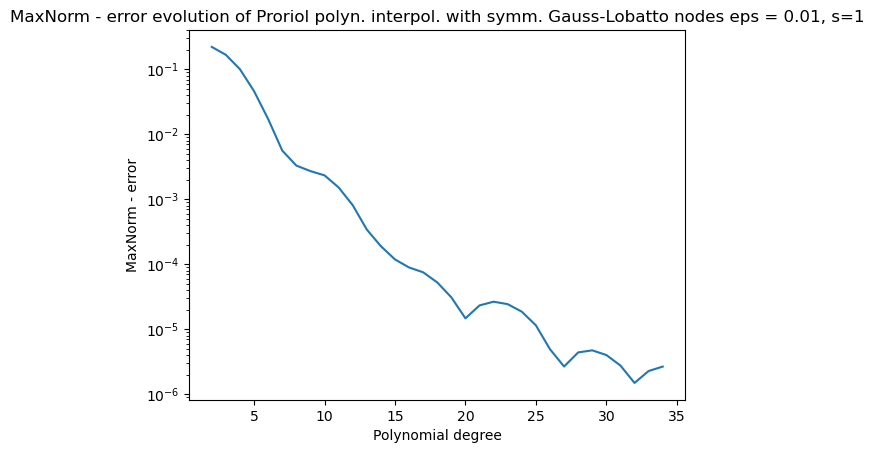

In [22]:
deg_vector_pro_e01_s1 = np.array(range(2, 35))
eps_01_p = 0.01
s_e01_p = -1/3
err_e01_s01_p = []

for m in tqdm(deg_vector_pro_e01_s1):
    nodals_e01_s1_p = gauss_lobatto_nodes(m)
    test_e01_s1_p = gauss_lobatto_nodes(5*m)
    f_values_pro_e01_s1 = f(np.transpose(test_e01_s1_p), eps_01_p, s_e01_p)
    Psi_f_values_e01_s1_p = np.asarray(pro_interpol(np.transpose(test_e01_s1_p), m, nodals_e01_s1_p, eps_01_p, s_e01_p))
    err_e01_s01_p.append(np.max(abs((f_values_pro_e01_s1 - Psi_f_values_e01_s1_p)/f_values_pro_e01_s1)))


error_plot = plt.semilogy(deg_vector_pro_e01_s1, err_e01_s01_p)
plt.title('MaxNorm - error evolution of Proriol polyn. interpol. with symm. Gauss-Lobatto nodes eps = 0.01, s=1')
plt.xlabel('Polynomial degree')
plt.ylabel('MaxNorm - error')

Text(0, 0.5, 'MaxNorm - error')

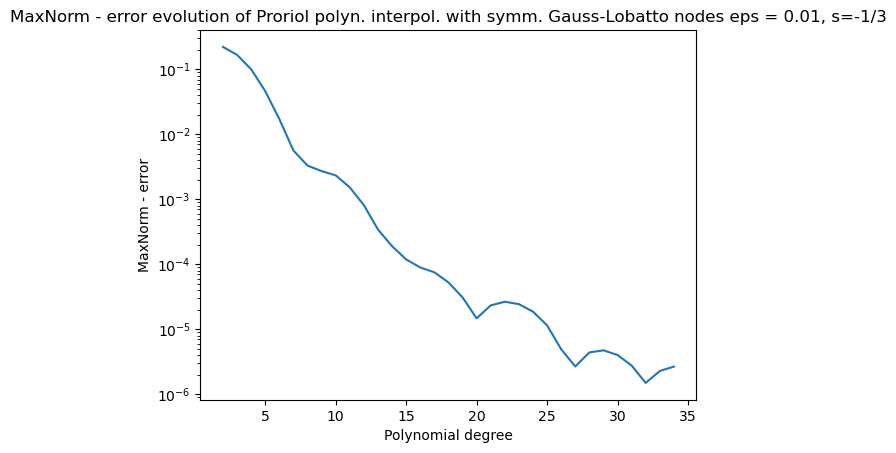

In [4]:
err_e01_s01_p = [0.2223225347065298, 0.16779762400044074, 0.10067637792576015, 0.04630543589140074, 0.017251091798276042, 0.005642520011688227, 0.0033140692635547924, 0.0027252742927612174, 0.002342704683427962, 0.0015281614510768368, 0.0008147507471624411, 0.00034333456698480404, 0.0001903064618197223, 0.00011903472570057853, 8.947641931955803e-05, 7.541097010991998e-05, 5.269926076277787e-05, 3.103033427659741e-05, 1.47543148589054e-05, 2.332806219781049e-05, 2.6599657647680658e-05, 2.4388532990617395e-05, 1.8684221434131484e-05, 1.1511465069367332e-05, 4.9372794916843225e-06, 2.6734329576823563e-06, 4.40925877739802e-06, 4.7459293501464e-06, 4.018977775114647e-06, 2.7692543479269353e-06, 1.495049487608458e-06, 2.281514144012822e-06, 2.666567751443438e-06]
deg_vector_pro_e01_s1 = np.array(range(2, 35))
error_plot = plt.semilogy(deg_vector_pro_e01_s1, err_e01_s01_p)
plt.title('MaxNorm - error evolution of Proriol polyn. interpol. with symm. Gauss-Lobatto nodes eps = 0.01, s=-1/3')
plt.xlabel('Polynomial degree')
plt.ylabel('MaxNorm - error')

[0.2223225347065298, 0.16779762400044074, 0.10067637792576015, 0.04630543589140074, 0.017251091798276042, 0.005642520011688227, 0.0033140692635547924, 0.0027252742927612174, 0.002342704683427962, 0.0015281614510768368, 0.0008147507471624411, 0.00034333456698480404, 0.0001903064618197223, 0.00011903472570057853, 8.947641931955803e-05, 7.541097010991998e-05, 5.269926076277787e-05, 3.103033427659741e-05, 1.47543148589054e-05, 2.332806219781049e-05, 2.6599657647680658e-05, 2.4388532990617395e-05, 1.8684221434131484e-05, 1.1511465069367332e-05, 4.9372794916843225e-06, 2.6734329576823563e-06, 4.40925877739802e-06, 4.7459293501464e-06, 4.018977775114647e-06, 2.7692543479269353e-06, 1.495049487608458e-06, 2.281514144012822e-06, 2.666567751443438e-06]


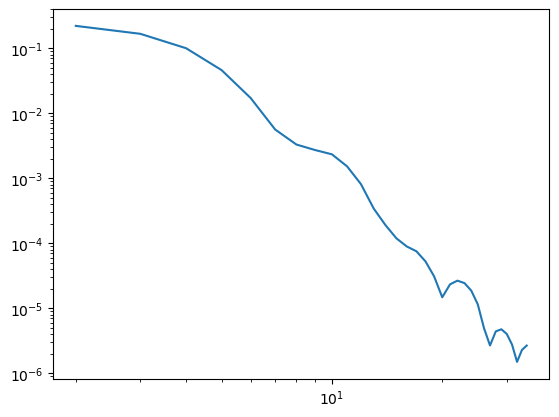

In [25]:
plt.loglog(deg_vector_pro_e01_s1, err_e01_s01_p)
print(err_e01_s01_p)

-0.4822224970242999


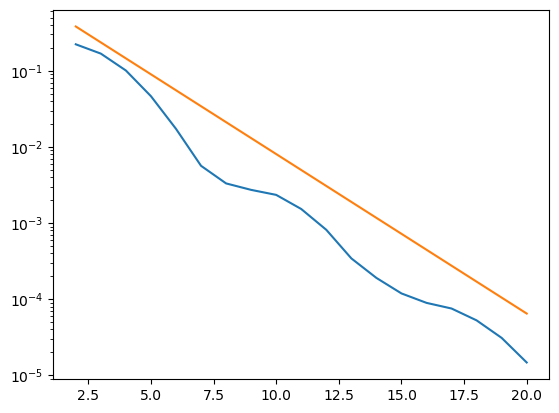

In [7]:
alpha_e01_s1_p = np.mean(np.log(np.array(err_e01_s01_p[1:20])/np.array(err_e01_s01_p[0:19])))
print(alpha_e01_s1_p)

line_fit_p_e01_s1 = np.exp(alpha_e01_s1_p*deg_vector_pro_e01_s1[0:19])

plt.semilogy(deg_vector_pro_e01_s1[0:19], err_e01_s01_p[0:19])
plt.semilogy(deg_vector_pro_e01_s1[0:19], line_fit_p_e01_s1)
plt.show()

100%|██████████████████████████████████████████████████████████████████████████████████| 11/11 [06:42<00:00, 36.59s/it]


Text(0, 0.5, 'MaxNorm - error')

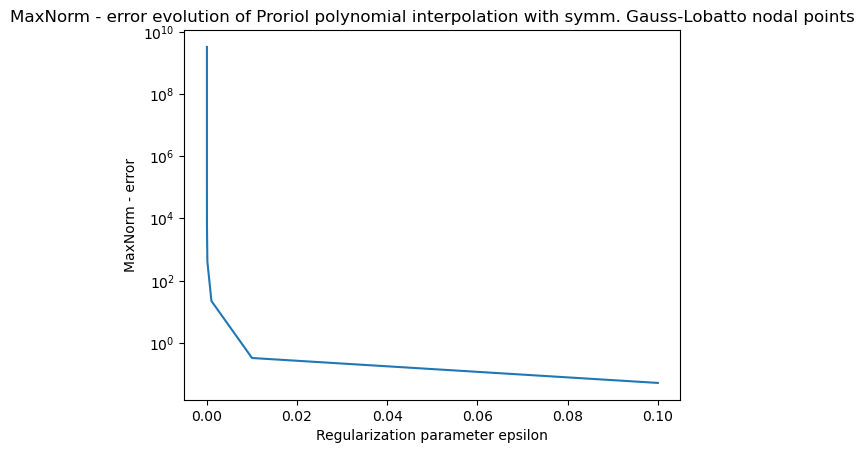

In [68]:
deg_vector_pro = np.array(range(5,16, 1))
epsilon_vector_pro = [0.1, 0.01, 0.001, 0.0001, 0.00001, 0.00001, 0.000001, 0.0000001, 0.00000001, 0.000000001, 0.0000000001]
s_pro = 1
err_pro = []

pro_index = 0

for m in tqdm(deg_vector_pro):
    eps_loop_pro = epsilon_vector_pro[pro_index]
    nodes_pro = gauss_lobatto_nodes(m)
    test_set_pro = gauss_lobatto_nodes(5*m) #test values for the interpolation
    #print(test_set_pro[0])
    f_values_pro = f(np.transpose(test_set_pro), eps_loop_pro, s_pro)
    #print('f shape', np.shape(f_values_pro), 'at step', m)
    Psi_f_values_pro = np.asarray(pro_interpol(np.transpose(test_set_pro), m, nodes_pro, eps_loop_pro, s_pro))
    #print('psi shape', np.shape(Psi_f_values_pro), 'at step', m)
    err_pro.append(np.max(abs((f_values_pro - Psi_f_values_pro)/f_values_pro)))
    pro_index = pro_index + 1


error_plot = plt.loglog(epsilon_vector_pro,err_pro)
plt.title('MaxNorm - error evolution of Proriol polynomial interpolation with symm. Gauss-Lobatto nodal points')
plt.xlabel('Regularization parameter epsilon')
plt.ylabel('MaxNorm - error')


In [62]:
#direct comparison for fixed epsilons

comparison_eps = [0.0001, 0.00001, 0.000001]

deg_vector_c = np.array(range(6,17, 1))
err_pro_c = []
err_eq_c = []

for eps_c_loop in comparison_eps:
    print(eps_c_loop)
    for m in tqdm(deg_vector_c):
        
        nodes_gll = gauss_lobatto_nodes(m)
        test_points_gll = gauss_lobatto_nodes(5*m)
        psi_vals = pro_interpol(test_points_gll, m, nodes_gll, eps_c_loop, 1)
        f_vals_gll = f(test_points_gll, eps_c_loop, 1)
        err_pro_c.append(np.max(abs(f_vals_gll - psi_vals)/f_vals_gll))
        
        
        test_points_e = equid(5*m)
        nodes_e = equid(m)
        f_vals_e = f(test_points_e[0], eps_c_loop, 1)
        #print(np.transpose(test_points_e[0])[2])
        L_f_e = np.asarray([Lagrange_interpol(x[0], x[1], m, eps_c_loop, 1) for x in np.transpose(test_points_e[0])])
        err_eq_c.append(np.max(abs(f_vals_e - L_f_e)/f_vals_e))

err_pro_c_1 = err_pro_c[0:11]
err_pro_c_2 = err_pro_c[11:22]
err_pro_c_3 = err_pro_c[22:33]

err_eq_c_1 = err_eq_c[0:11]
err_eq_c_2 = err_eq_c[11:22]
err_eq_c_3 = err_eq_c[22:33]

    

0.0001


100%|██████████████████████████████████████████████████████████████████████████████████| 11/11 [03:15<00:00, 17.80s/it]


1e-05


100%|██████████████████████████████████████████████████████████████████████████████████| 11/11 [03:20<00:00, 18.22s/it]


1e-06


100%|██████████████████████████████████████████████████████████████████████████████████| 11/11 [03:24<00:00, 18.58s/it]


In [135]:
print(err_pro_c_1)

[0.06385819892237274, 0.0012375576344903268, 0.028264529033616082, 0.04270295269823046, 0.04944408809831537, 0.05182884400148694, 0.0515269596818064, 0.049466475836872616, 0.04623040668296313, 0.04223248564960476, 0.037793779825495116]


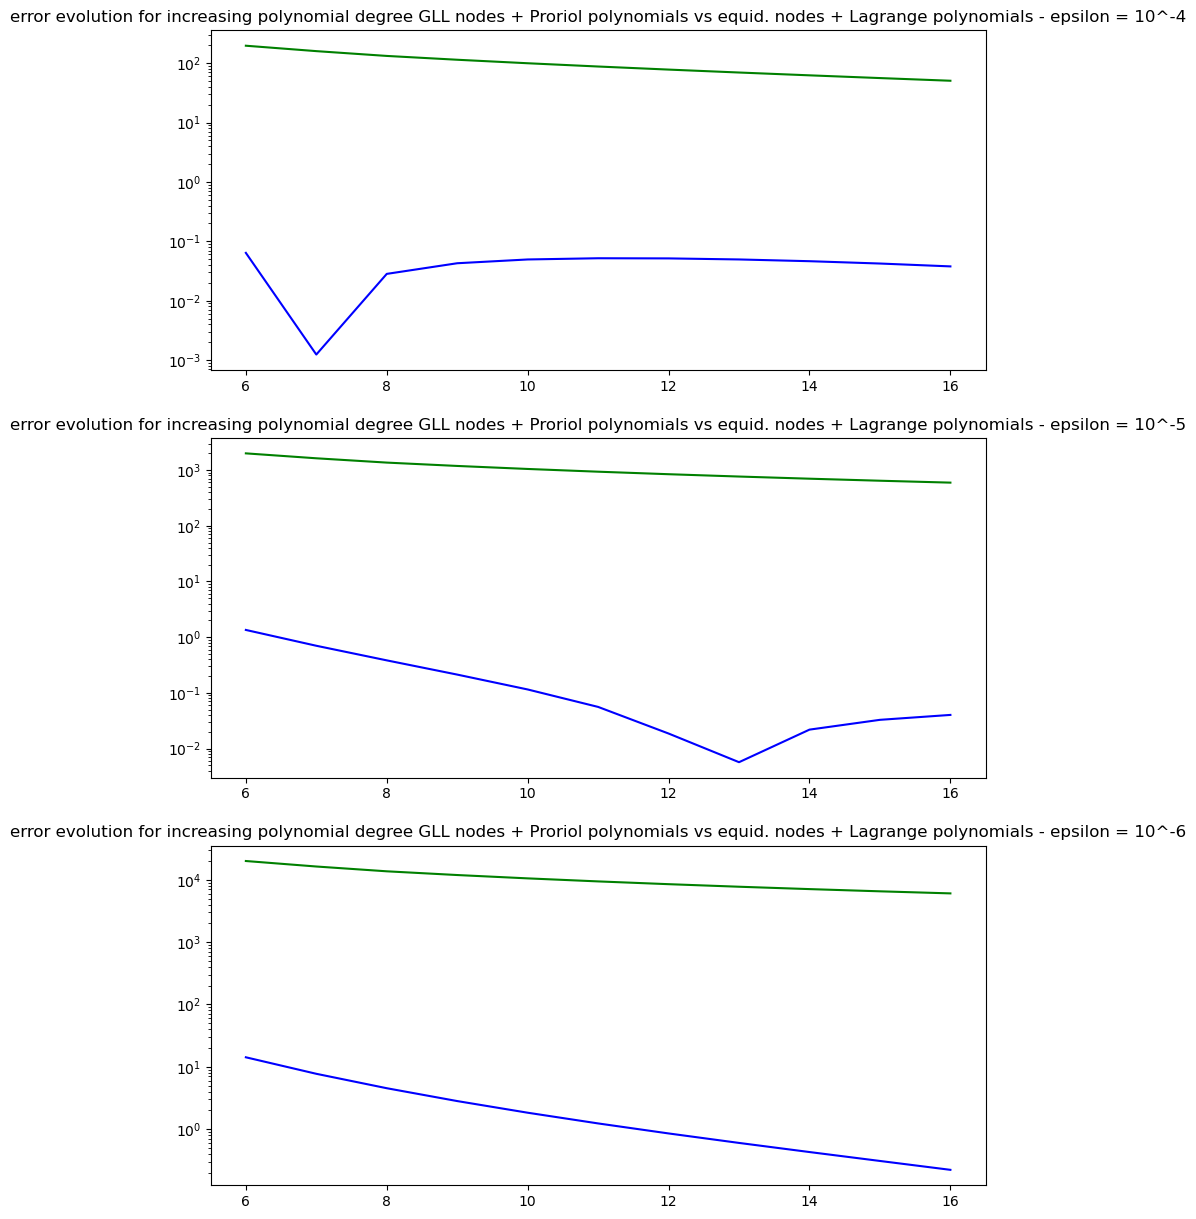

In [63]:
fig, ax = plt.subplots(nrows = 3, ncols = 1, figsize = (10,15))

ax[0].semilogy(deg_vector_c, err_pro_c_1, color = 'b')
ax[0].semilogy(deg_vector_c, err_eq_c_1, color = 'g')
ax[0].set_title('error evolution for increasing polynomial degree GLL nodes + Proriol polynomials vs equid. nodes + Lagrange polynomials - epsilon = 10^-4')

ax[1].semilogy(deg_vector_c, err_pro_c_2, color = 'b')
ax[1].semilogy(deg_vector_c, err_eq_c_2, color = 'g')
ax[1].set_title('error evolution for increasing polynomial degree GLL nodes + Proriol polynomials vs equid. nodes + Lagrange polynomials - epsilon = 10^-5')

ax[2].semilogy(deg_vector_c, err_pro_c_3, color = 'b')
ax[2].semilogy(deg_vector_c, err_eq_c_3, color = 'g')
ax[2].set_title('error evolution for increasing polynomial degree GLL nodes + Proriol polynomials vs equid. nodes + Lagrange polynomials - epsilon = 10^-6')

plt.show()

In [66]:
#direct comparison for fixed epsilons

comparison_s = [2, 4, 6, 8]

deg_vector_c = np.array(range(6,17, 1))
err_pro_s = []
err_eq_s = []

for s_loop_c in comparison_s:
    print(s_loop_c)
    for m in tqdm(deg_vector_c):
        
        nodes_gll = gauss_lobatto_nodes(m)
        test_points_gll = gauss_lobatto_nodes(5*m)
        psi_vals = pro_interpol(test_points_gll, m, nodes_gll, 0.1, s_loop_c)
        f_vals_gll = f(test_points_gll, 0.1, s_loop_c)
        err_pro_s.append(np.max(abs(f_vals_gll - psi_vals)/f_vals_gll))
        
        
        test_points_e = equid(5*m)
        nodes_e = equid(m)
        f_vals_e = f(test_points_e[0], 0.1, s_loop_c)
        #print(np.transpose(test_points_e[0])[2])
        L_f_e = np.asarray([Lagrange_interpol(x[0], x[1], m, 0.1, s_loop_c) for x in np.transpose(test_points_e[0])])
        err_eq_s.append(np.max(abs(f_vals_e - L_f_e)/f_vals_e))

err_pro_s_1 = err_pro_s[0:11]
err_pro_s_2 = err_pro_s[11:22]
err_pro_s_3 = err_pro_s[22:33]
err_pro_s_4 = err_pro_s[33:44]

err_eq_s_1 = err_eq_s[0:11]
err_eq_s_2 = err_eq_s[11:22]
err_eq_s_3 = err_eq_s[22:33]
err_eq_s_4 = err_eq_s[33:44]


2


100%|██████████████████████████████████████████████████████████████████████████████████| 11/11 [03:23<00:00, 18.48s/it]


4


100%|██████████████████████████████████████████████████████████████████████████████████| 11/11 [03:27<00:00, 18.90s/it]


6


100%|██████████████████████████████████████████████████████████████████████████████████| 11/11 [03:28<00:00, 18.98s/it]


8


100%|██████████████████████████████████████████████████████████████████████████████████| 11/11 [03:25<00:00, 18.68s/it]


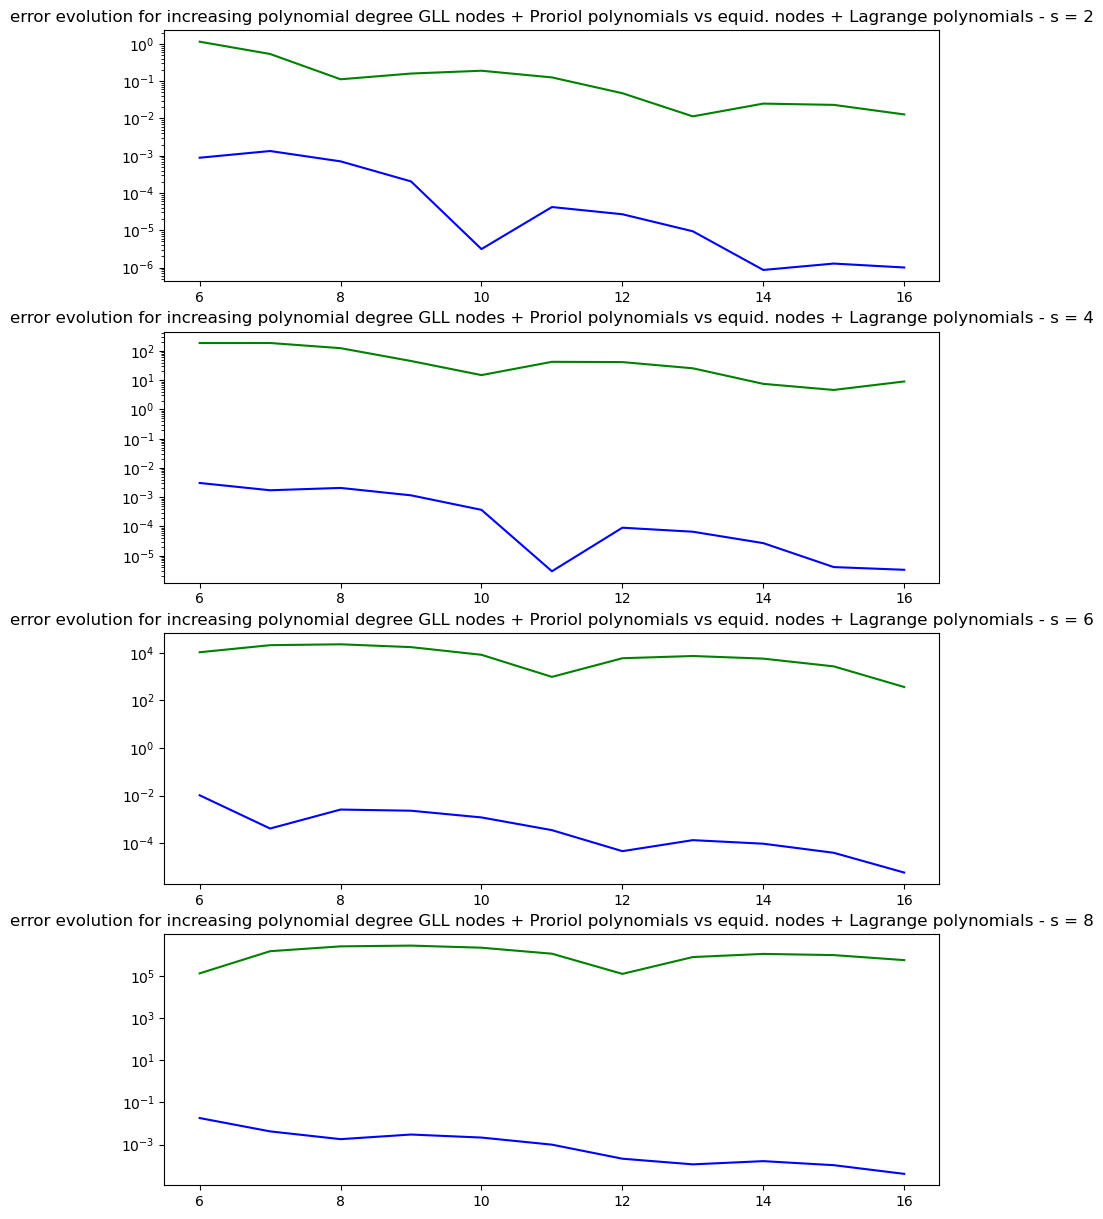

In [67]:
fig, ax = plt.subplots(nrows = 4, ncols = 1, figsize = (10,15))

ax[0].semilogy(deg_vector_c, err_pro_s_1, color = 'b')
ax[0].semilogy(deg_vector_c, err_eq_s_1, color = 'g')
ax[0].set_title('error evolution for increasing polynomial degree GLL nodes + Proriol polynomials vs equid. nodes + Lagrange polynomials - s = 2')

ax[1].semilogy(deg_vector_c, err_pro_s_2, color = 'b')
ax[1].semilogy(deg_vector_c, err_eq_s_2, color = 'g')
ax[1].set_title('error evolution for increasing polynomial degree GLL nodes + Proriol polynomials vs equid. nodes + Lagrange polynomials - s = 4')

ax[2].semilogy(deg_vector_c, err_pro_s_3, color = 'b')
ax[2].semilogy(deg_vector_c, err_eq_s_3, color = 'g')
ax[2].set_title('error evolution for increasing polynomial degree GLL nodes + Proriol polynomials vs equid. nodes + Lagrange polynomials - s = 6')

ax[3].semilogy(deg_vector_c, err_pro_s_4, color = 'b')
ax[3].semilogy(deg_vector_c, err_eq_s_4, color = 'g')
ax[3].set_title('error evolution for increasing polynomial degree GLL nodes + Proriol polynomials vs equid. nodes + Lagrange polynomials - s = 8')

plt.show()

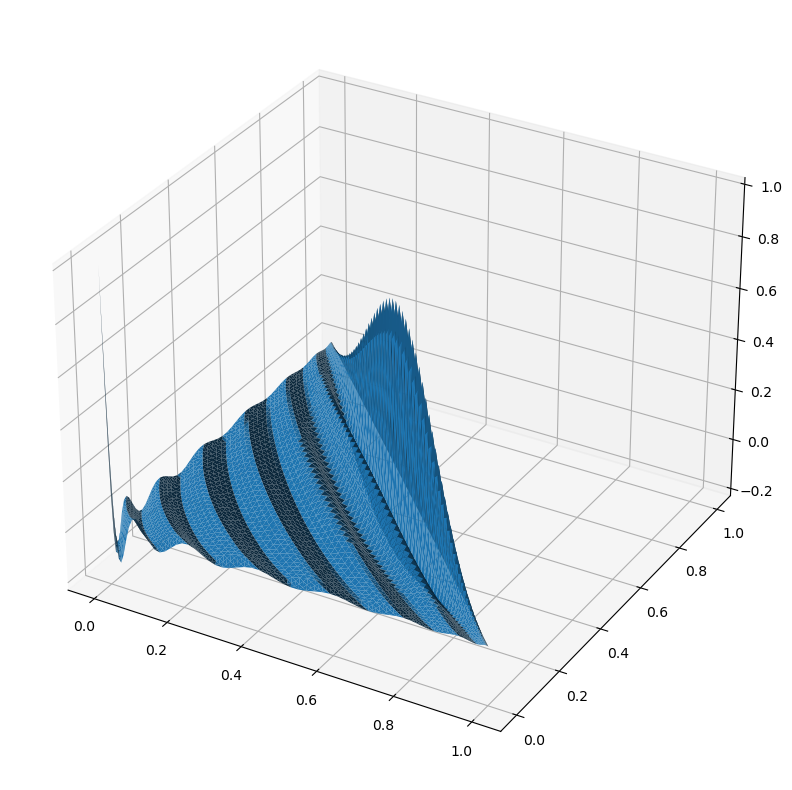

In [117]:
fig = plt.figure(figsize = [10,10])
ax = plt.axes(projection='3d')
ax.plot_trisurf(np.transpose(test_set_pro)[0], np.transpose(test_set_pro)[1], 
                Psi_f_values_pro)

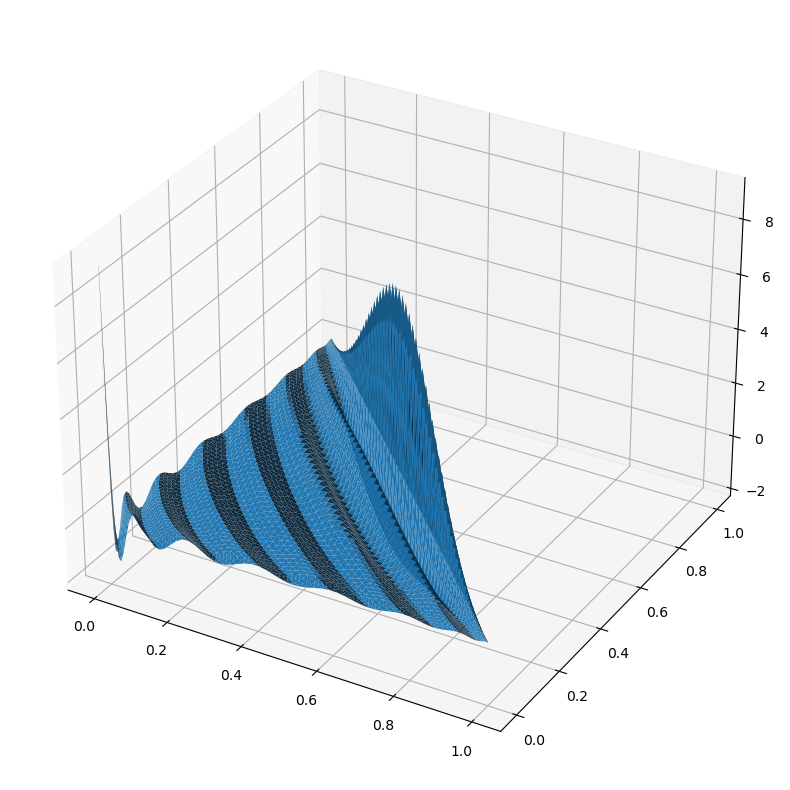

In [119]:
fig = plt.figure(figsize = [10,10])
ax = plt.axes(projection='3d')
ax.plot_trisurf(np.transpose(test_set_pro)[0], np.transpose(test_set_pro)[1], 
                Psi_f_values_pro - f_values_pro)

In [ ]:
m = 17
eps_01_p = 0.01
s_e01_p = 1

nodals_e01_s1_p = gauss_lobatto_nodes(m)
test_e01_s1_p = gauss_lobatto_nodes(5*m)
f_values_pro_e01_s1 = f(np.transpose(test_e01_s1_p), eps_01_p, s_e01_p)
Psi_f_values_e01_s1_p = np.asarray(pro_interpol(np.transpose(test_e01_s1_p), m, nodals_e01_s1_p, eps_01_p, s_e01_p))
#err_e01_s01_p.append(np.max(abs((f_values_pro_e01_s1 - Psi_f_values_e01_s1_p)/f_values_pro_e01_s1)))

In [ ]:
fig = plt.figure(figsize = [10,10])
ax = plt.axes(projection='3d')
ax.plot_trisurf(np.transpose(test_set_pro)[0], np.transpose(test_set_pro)[1], 
                f_values_pro)

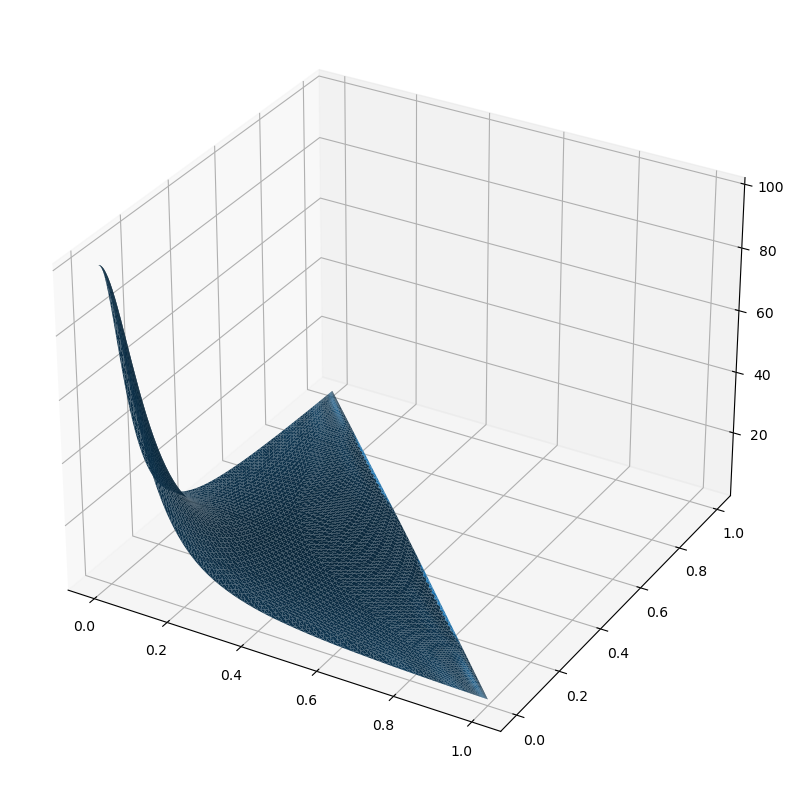

In [98]:
fig = plt.figure(figsize = [10,10])
ax = plt.axes(projection='3d')
ax.plot_trisurf(np.transpose(test_e01_s1_p)[0], np.transpose(test_e01_s1_p)[1], 
                Psi_f_values_e01_s1_p)

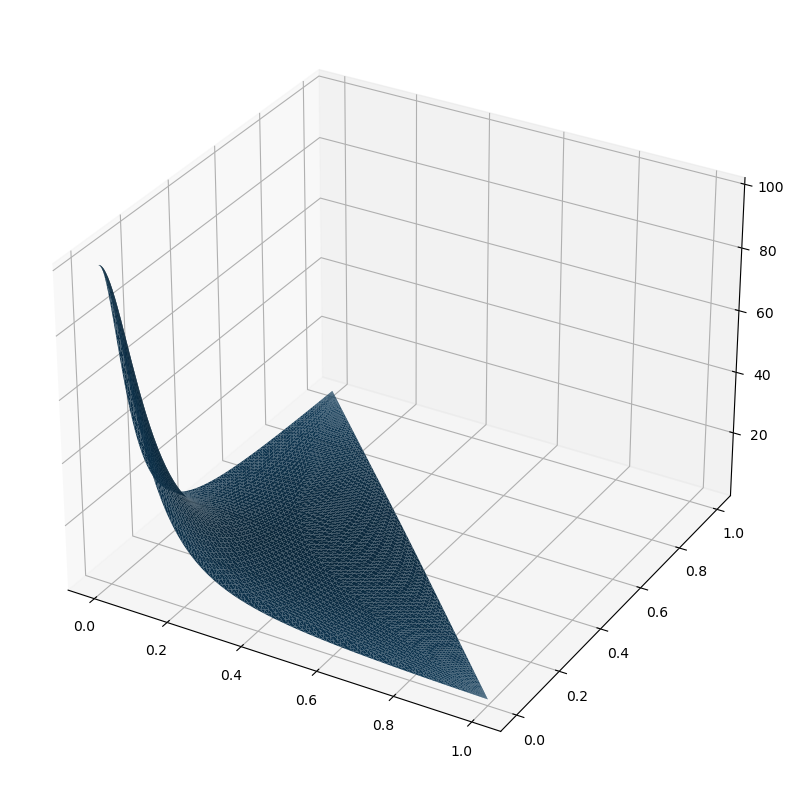

In [99]:
fig = plt.figure(figsize = [10,10])
ax = plt.axes(projection='3d')
ax.plot_trisurf(np.transpose(test_e01_s1_p)[0], np.transpose(test_e01_s1_p)[1], 
                f_values_pro_e01_s1)

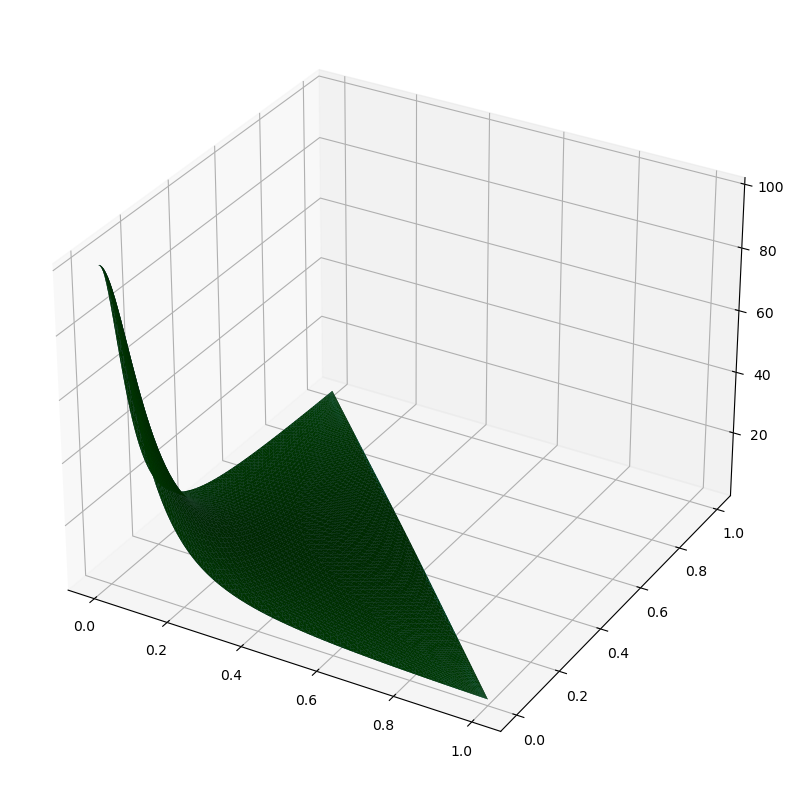

In [36]:
fig = plt.figure(figsize = [10,10])

ax = plt.axes(projection='3d')
ax.plot_trisurf(np.transpose(test_e01_s1_p)[0], np.transpose(test_e01_s1_p)[1], 
                Psi_f_values_e01_s1_p)

#ax = plt.axes(projection='3d')
ax.plot_trisurf(np.transpose(test_e01_s1_p)[0], np.transpose(test_e01_s1_p)[1], 
                f_values_pro_e01_s1, color = 'g')


plt.show()
plt.close(fig=fig)


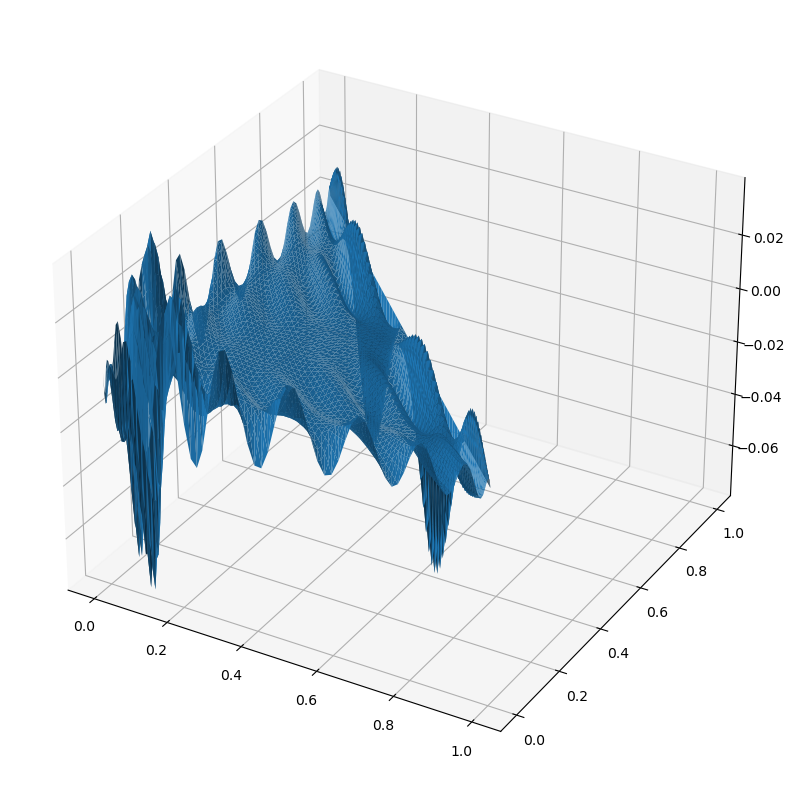

In [100]:
fig = plt.figure(figsize = [10,10])
ax = plt.axes(projection='3d')
ax.plot_trisurf(np.transpose(test_e01_s1_p)[0], np.transpose(test_e01_s1_p)[1], 
                Psi_f_values_e01_s1_p - f_values_pro_e01_s1)

In [26]:
plot_eps = 0.01
plot_deg = 17
plot_s = 1

plot_nodes = equid(plot_deg)[0]
plot_test_points = equid(5*plot_deg)[0]
f_plot_vals = f(plot_test_points, plot_eps, plot_s)
L_f_plot = np.asarray([Lagrange_interpol(x[0], x[1], plot_deg, plot_eps, plot_s) for x in np.transpose(plot_test_points)])

In [ ]:
plot_eps = 0.01
plot_deg = 17
plot_s = 1

plot_nodes = equid(plot_deg)[0]
plot_test_points = equid(5*plot_deg)[0]
f_plot_vals = f(plot_test_points, plot_eps, plot_s)
L_f_plot = np.asarray([Lagrange_interpol(x[0], x[1], plot_deg, plot_eps, plot_s) for x in np.transpose(plot_test_points)])

In [112]:
print(len(L_f_plot))

3741


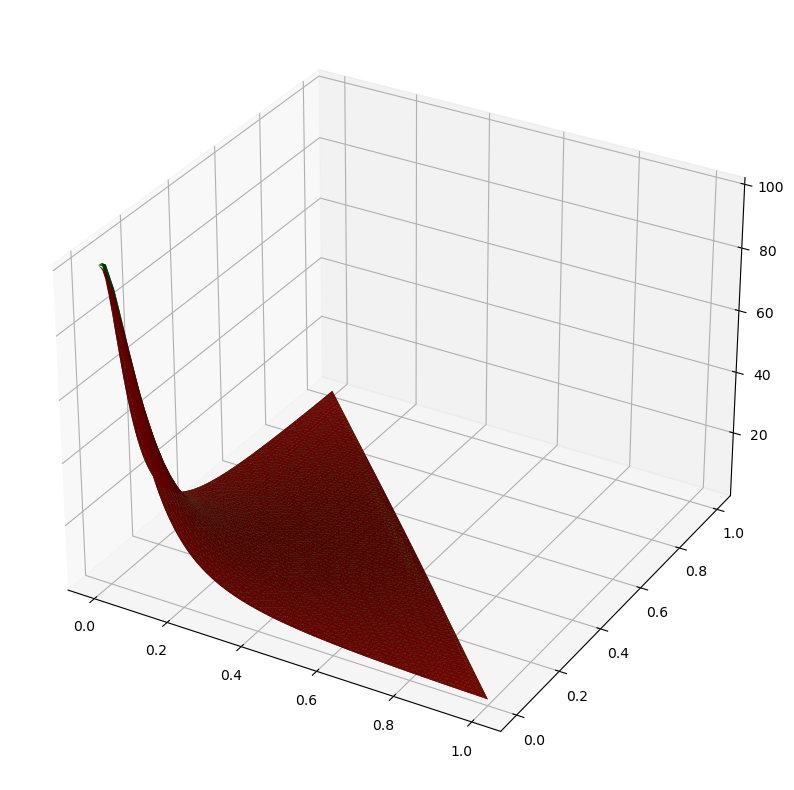

In [33]:
fig = plt.figure(figsize = [10,10])
ax = plt.axes(projection='3d')
ax.plot_trisurf(plot_test_points[0], plot_test_points[1], 
                L_f_plot, color = 'g')

#ax = plt.axes(projection='3d')
ax.plot_trisurf(plot_test_points[0], plot_test_points[1], 
                f_plot_vals, color = 'r')

plt.show()

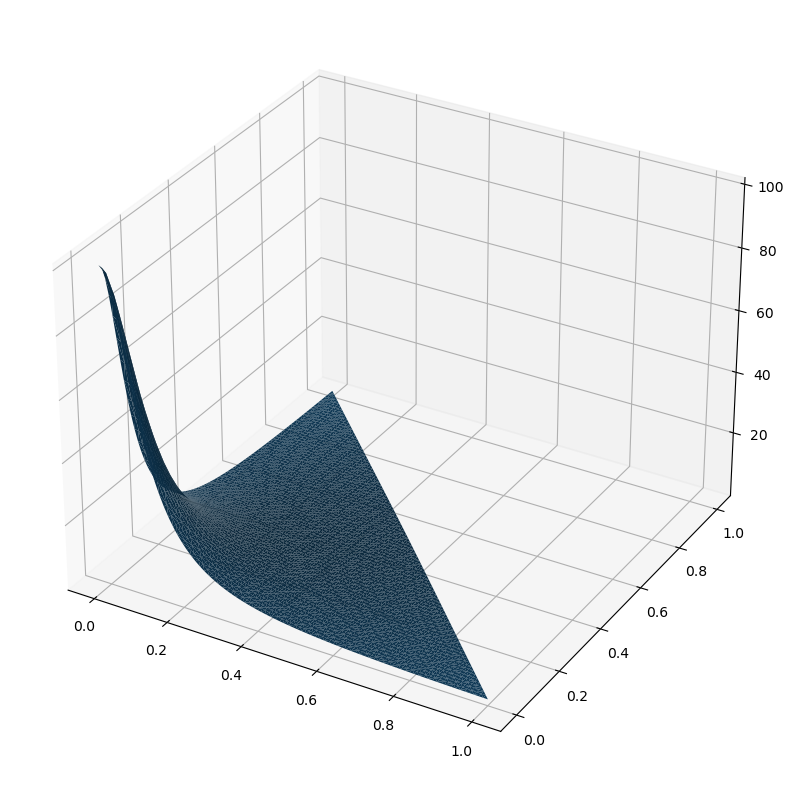

In [116]:
fig = plt.figure(figsize = [10,10])
ax = plt.axes(projection='3d')
ax.plot_trisurf(plot_test_points[0], plot_test_points[1], 
                f_plot_vals)

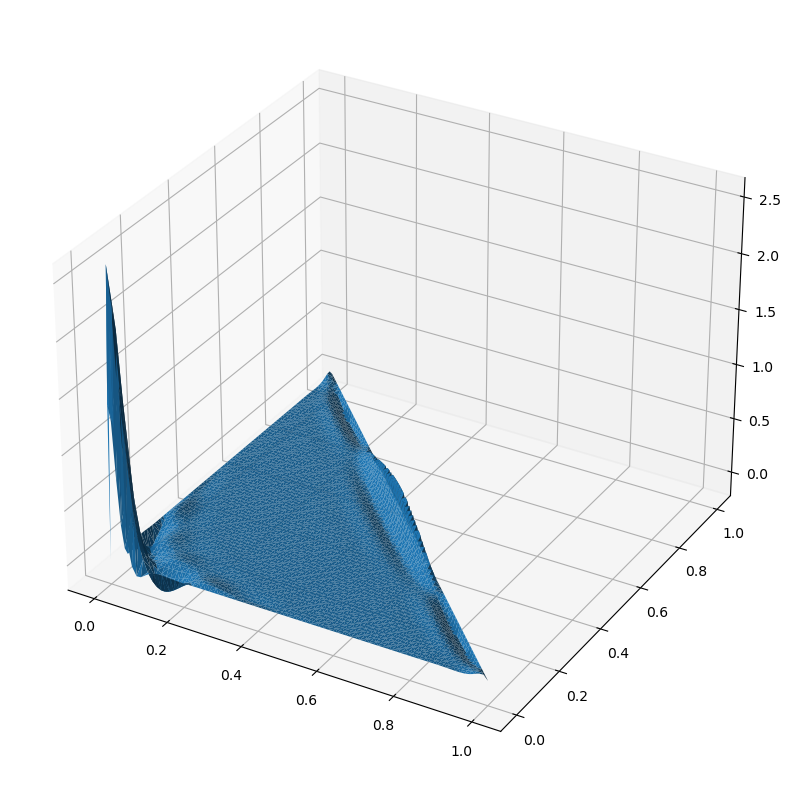

In [114]:
fig = plt.figure(figsize = [10,10])
ax = plt.axes(projection='3d')
ax.plot_trisurf(plot_test_points[0], plot_test_points[1], 
                L_f_plot - f_plot_vals)